# Projected separation between the two galaxies in NGC 477

This notebook computes the projected angular separation between the two galaxies using the WCS of the HI data cube used in `Galaxy-preview.ipynb`.

The centers are the same pixel centers used there to isolate each galaxy:

- Galaxy 1: `(x, y) = (30, 32)`
- Galaxy 2: `(x, y) = (53, 23)`

The projected physical separation is computed with the small-angle relation:

`separation = angular_separation_rad * distance`

We use the NED mean redshift-independent distance shown in the data base, `D = 90.063 Mpc`, and also report the value using the NED Hubble distance, `D = 82.74 Mpc`, for comparison.

In [9]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.io import fits
from astropy.wcs import WCS

In [10]:
# Data cube path used in Galaxy-preview.ipynb
data_dir = Path("/home/angeldavid/Desktop/Fedora/RESEARCH-INTERSHIPS/data_cubes/S0121+3848")
cube_path = data_dir / "S0116+4114_HIcube2_clean_smooth_image_4_cube.fits"

header = fits.getheader(cube_path)
data_cube = fits.getdata(cube_path)
wcs = WCS(header).celestial

print("Cube shape:", data_cube.shape)
print("Spatial pixel scale:", wcs.proj_plane_pixel_scales()[0].to(u.arcsec))

Cube shape: (71, 63, 75)
Spatial pixel scale: 6.0000012 arcsec


## Galaxy centers

These are the two centers used in `Galaxy-preview.ipynb` to make the circular masks for the two galaxies. FITS/WCS pixel coordinates below are zero-indexed, matching NumPy and Matplotlib image coordinates.

In [11]:
galaxy_centers_pix = {
    "Galaxy 1": (32, 34),
    "Galaxy 2": (53, 23),
}

galaxy_coords = {}

for name, (x, y) in galaxy_centers_pix.items():
    ra_deg, dec_deg = wcs.pixel_to_world_values(x, y)
    galaxy_coords[name] = SkyCoord(ra=ra_deg * u.deg, dec=dec_deg * u.deg, frame="icrs")
    print(f"{name}: x={x:5.1f}, y={y:5.1f}, RA={ra_deg:.8f} deg, Dec={dec_deg:.8f} deg")

Galaxy 1: x= 32.0, y= 34.0, RA=20.33306764 deg, Dec=40.48919924 deg
Galaxy 2: x= 53.0, y= 23.0, RA=20.28673372 deg, Dec=40.47136090 deg


## Angular and projected physical separation

In [12]:
coord_1 = galaxy_coords["Galaxy 1"]
coord_2 = galaxy_coords["Galaxy 2"]

angular_sep = coord_1.separation(coord_2)

# Distances from the NED screenshot.
ned_mean_distance_mpc = 90.063
ned_hubble_distance_mpc = 82.74

projected_sep_mean_mpc = angular_sep.to(u.rad).value * ned_mean_distance_mpc
projected_sep_hubble_mpc = angular_sep.to(u.rad).value * ned_hubble_distance_mpc

print(f"Angular separation: {angular_sep.deg:.8f} deg")
print(f"Angular separation: {angular_sep.arcmin:.6f} arcmin")
print(f"Angular separation: {angular_sep.arcsec:.6f} arcsec")
print()
print(f"Projected separation using D = {ned_mean_distance_mpc:.3f} Mpc: {projected_sep_mean_mpc:.6f} Mpc = {projected_sep_mean_mpc * 1000:.3f} kpc")
print(f"Projected separation using D = {ned_hubble_distance_mpc:.2f} Mpc: {projected_sep_hubble_mpc:.6f} Mpc = {projected_sep_hubble_mpc * 1000:.3f} kpc")

Angular separation: 0.03950027 deg
Angular separation: 2.370016 arcmin
Angular separation: 142.200974 arcsec

Projected separation using D = 90.063 Mpc: 0.062090 Mpc = 62.090 kpc
Projected separation using D = 82.74 Mpc: 0.057042 Mpc = 57.042 kpc


Expected result with the current centers:

- Angular separation: `148.146 arcsec` = `2.469 arcmin`
- Projected separation at `D = 90.063 Mpc`: `0.06469 Mpc` = `64.69 kpc`
- Projected separation at `D = 82.74 Mpc`: `0.05943 Mpc` = `59.43 kpc`

For the adopted NED mean distance, the projected separation is therefore approximately **64.7 kpc**.

## Visual check on the HI moment-0 map

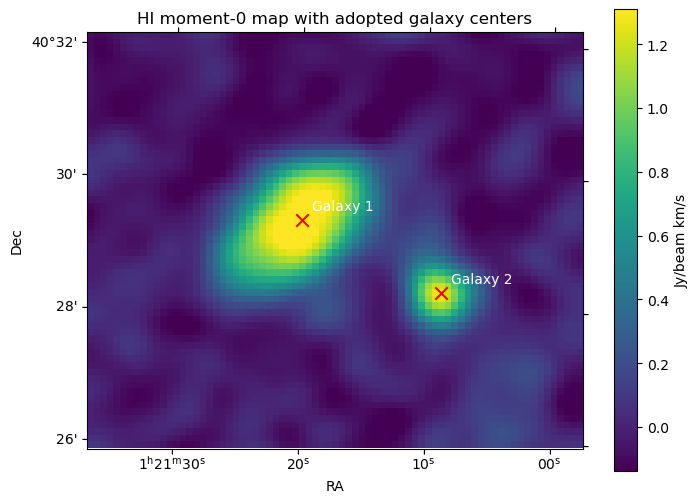

In [13]:
# Build a simple moment-0 image for a visual sanity check.
c_kms = 299792.458
f0_mhz = 1420.40575
freq_mhz = (header["CRVAL3"] + np.arange(header["NAXIS3"]) * header["CDELT3"]) / 1e6
vel_kms = c_kms * (freq_mhz - f0_mhz) / f0_mhz
dv_kms = np.abs(np.nanmedian(np.diff(vel_kms)))

mom0 = np.nansum(data_cube, axis=0) * dv_kms

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection=wcs)
im = ax.imshow(mom0, origin="lower", cmap="viridis", vmin=np.nanpercentile(mom0, 5), vmax=np.nanpercentile(mom0, 99))

for name, (x, y) in galaxy_centers_pix.items():
    ax.scatter(x, y, s=80, marker="x", color="red", transform=ax.get_transform("pixel"))
    ax.text(x + 1.5, y + 1.5, name, color="white", transform=ax.get_transform("pixel"))

ax.set_xlabel("RA")
ax.set_ylabel("Dec")
ax.set_title("HI moment-0 map with adopted galaxy centers")
fig.colorbar(im, ax=ax, label="Jy/beam km/s")
plt.show()

## Distance choice and comparison table

The angular separation is fixed by the sky positions of the two galaxies. The physical projected separation changes linearly with the distance adopted for the system.

A redshift-based distance can be estimated with the Hubble law:

`D = cz / H0`

Using the NED heliocentric velocity from the screenshot, `cz = 5876 km/s`, and `H0 = 67.8 km/s/Mpc`, this gives `D = 86.67 Mpc`. This is slightly different from the NED Hubble distance listed in the screenshot, because NED reports a velocity-frame/cosmology-corrected value. The projected separation therefore changes slightly depending on which distance is adopted.

In [27]:
import pandas as pd

# reshif NED data base
cz_helio_kms = 5876
H0 = 67.8
redshift_distance_mpc = cz_helio_kms / H0

# reshift SIMBAD data base
cz_simbad = 5927.28 #km/s
redshift_distance_mpc_simbad = cz_simbad / H0
distance_options = [
    {
        "Distance choice": "NED Hubble distance (CMB)",
        "Distance [Mpc]": ned_hubble_distance_mpc,
        "Notes": "Value listed in NED",
    },
    {
        "Distance choice": "Redshift estimate, cz/H0",
        "Distance [Mpc]": redshift_distance_mpc,
        "Notes": f"cz={cz_helio_kms} km/s, H0={H0} km/s/Mpc",
    },
    {
        "Distance choice": "NED mean redshift-independent distance",
        "Distance [Mpc]": ned_mean_distance_mpc,
        "Notes": "Adopted value for the main result",
    },
    
    {
        "Distance choice": "SIMBAD data base",
        "Distance [Mpc]": redshift_distance_mpc_simbad, 
        "Notes": "Rehshif and cz taken from SIMBAD DB",
    },

]

comparison = pd.DataFrame(distance_options)
comparison["Angular separation [arcsec]"] = angular_sep.arcsec
comparison["Projected separation [Mpc]"] = angular_sep.to(u.rad).value * comparison["Distance [Mpc]"]
comparison["Projected separation [kpc]"] = 1000 * comparison["Projected separation [Mpc]"]
comparison = comparison[
    [
        "Distance choice",
        "Distance [Mpc]",
        "Angular separation [arcsec]",
        "Projected separation [Mpc]",
        "Projected separation [kpc]",
        "Notes",
    ]
]

comparison.round(
    {
        "Distance [Mpc]": 3,
        "Angular separation [arcsec]": 3,
        "Projected separation [Mpc]": 5,
        "Projected separation [kpc]": 2,
    }
)

,Distance choice,Distance [Mpc],Angular separation [arcsec],Projected separation [Mpc],Projected separation [kpc],Notes
0,NED Hubble distance (CMB),82.740,142.201,0.05704,57.04,Value listed in NED
1,"Redshift estimate, cz/H0",86.667,142.201,0.05975,59.75,"cz=5876 km/s, H0=67.8 km/s/Mpc"
2,NED mean redshift-independent distance,90.063,142.201,0.06209,62.09,Adopted value for the main result
3,SIMBAD data base,87.423,142.201,0.06027,60.27,Rehshif and cz taken from SIMBAD DB
